<a href="https://colab.research.google.com/github/E-tech-coder/House_prices_prediction/blob/main/copy_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')
print("house_prices_advanced_regression_techniques_path")

100%|██████████| 199k/199k [00:00<00:00, 291kB/s]

Extracting files...
Data source import complete.
house_prices_advanced_regression_techniques_path


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


# 1. Problem Definition


Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition provides the challenges to predict the final price of each home.

Kaggle :
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview


Practice Skills :

* Creative feature engineering

* Advanced regression techniques like random forest and gradient boosting



In [4]:
train = pd.read_csv("/root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques/train.csv")
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 2. Data Understanding
# 3. Data Cleaning

In [5]:
cat_columns = train.columns[[train[c].dtype == "object" for c in train.columns]]
num_columns = train.columns[[train[c].dtype != "object" for c in train.columns]]

In [6]:
train.shape

(1460, 81)

In the training dataset there are 1460 rows and 81 columns(79 features + ID + Sale Price), including 43 categorical features, 36 numerical features + ID + Sale Price.

* Numercial features : 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'.

       
* Categorical features : 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'



In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: title={'center': 'Number of missing values in related columns'}>

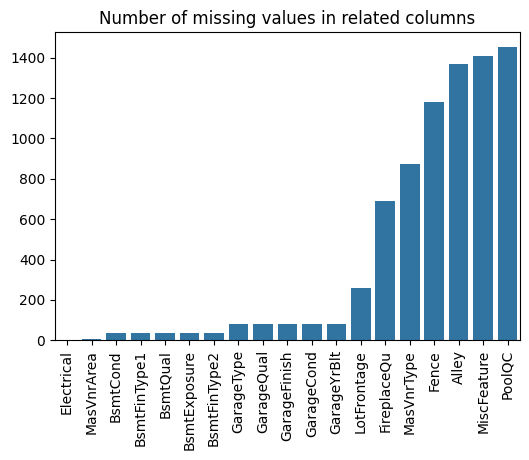

In [8]:
missing = train.isna().sum()
missing = missing[missing >0].sort_values(ascending = True)

plt.figure(figsize = (6,4))
plt.xticks(rotation = 90)
plt.title("Number of missing values in related columns")
sns.barplot(data = missing)

In [9]:
for x in ["Fence", "PoolQC", "MiscFeature", "Alley", "MasVnrType", "FireplaceQu"]:
  print(train[x].dtype)

object
object
object
object
object
object


There are 1460 records in this dataset.
In which there are 6 columns that have many missing values.

* There are more than 90% null values in "PoolQC" (Pool quality), "MiscFeature" (Miscellaneous feature not covered in other categories) and "Alley" (Type of alley access).

* 80% null values in "Fence" (Fence quality).

* Around 50% missing values in "MasVnrType"(Masonry veneer type) and "FireplaceQu"(Fireplace quality).

Since high proportion of missing values can damage the accuracy and stability of the prediction models and it is difficult to manually fill in the missing values in this case.
["Fence", "PoolQC", "MiscFeature", "Alley", "MasVnrType", "FireplaceQu"]



Fill in the missing values in categorical columns with "Missing" and explore the relationship of categorical columns with Sale Price.

In [10]:
len(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'])

43

In [11]:
for c in cat_columns:
  train[c] = train[c].astype("category")
  if train[c].isna().any() :
    train[c] = train[c].cat.add_categories("Missing")
    train[c] = train[c].fillna("Missing")

In [12]:
melted = pd.melt(train, id_vars="SalePrice", value_vars=cat_columns)
melted.head(10)

,SalePrice,variable,value
0,208500,MSZoning,RL
1,181500,MSZoning,RL
2,223500,MSZoning,RL
3,140000,MSZoning,RL
4,250000,MSZoning,RL
5,143000,MSZoning,RL
6,307000,MSZoning,RL
7,200000,MSZoning,RL
8,129900,MSZoning,RM
9,118000,MSZoning,RL


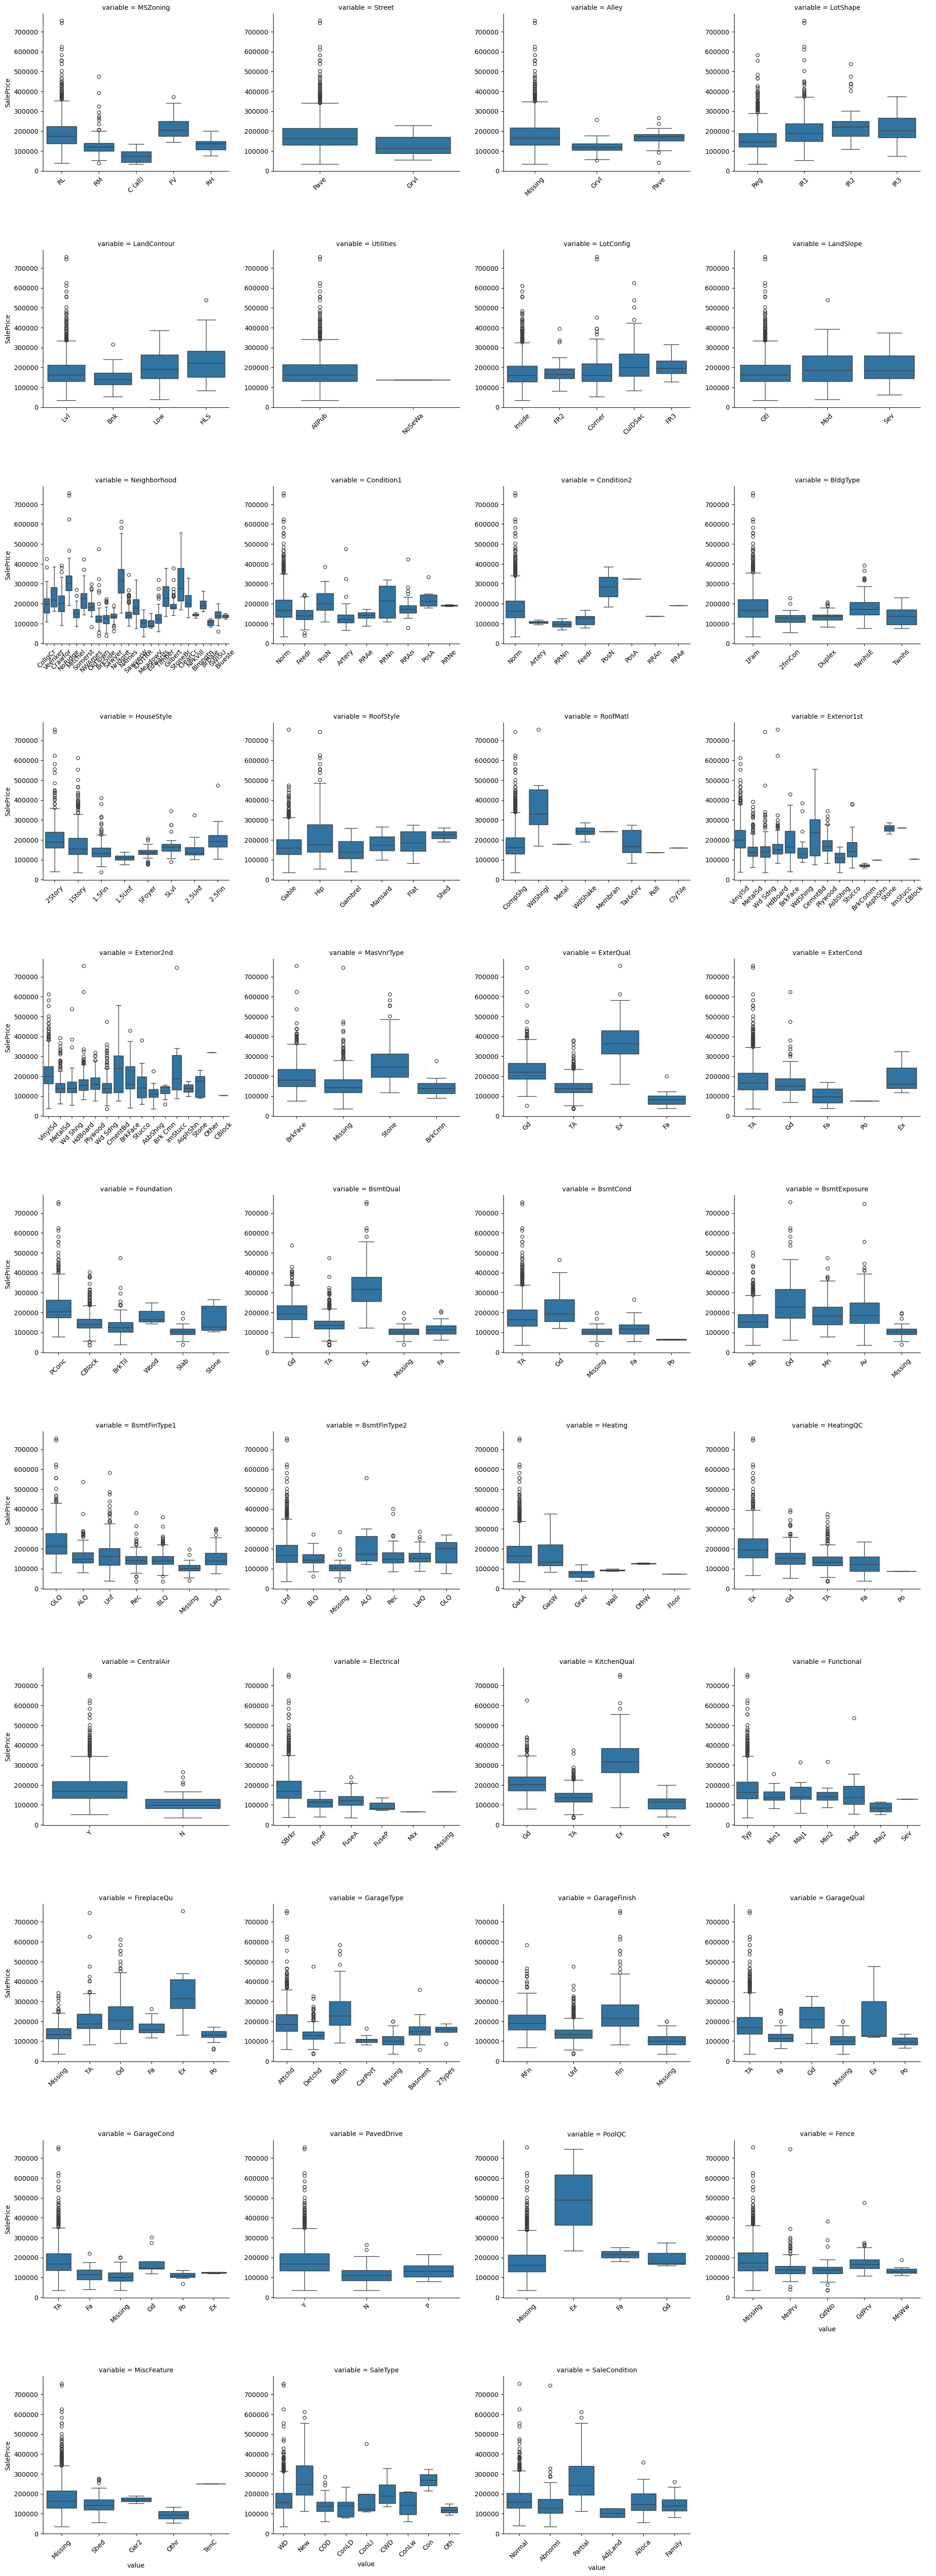

In [13]:
# g = sns.FacetGrid(data = melted, col = "variable", col_wrap = 4 , sharex= False, sharey= False)
# g.map_dataframe(sns.boxplot, x = "value", y = "SalePrice")

g = sns.catplot(
      data = melted,
      x = "value",
      y = "SalePrice",
      col = "variable",
      col_wrap = 4,
      sharex= False,
      sharey= False,
      kind = "box")

for ax in g.axes.flat:
  ax.tick_params(axis = "x", rotation = 45)

g.fig.subplots_adjust(hspace= 0.5)

Among all of these categorical features, Sales Prices are more heavily influenced by

Neighborhood the house is in,

proximity to the second road or railroad,

external covering,

the entailment of a basement or  a pool.

# Understanding the distribution of sales prices

# ONE WAY ANOVA

Which categorical features actually segment the market into different price levels? Is the difference of prices really result from belonging to different categories or just random noise?

Key assumptions :      

* independence of observations,
* normality of residuals (data within groups follow a normal distribution),
* homogeneity of variances (group variances are equal, also known as homoscedasticity)

<Axes: xlabel='SalePrice', ylabel='Count'>

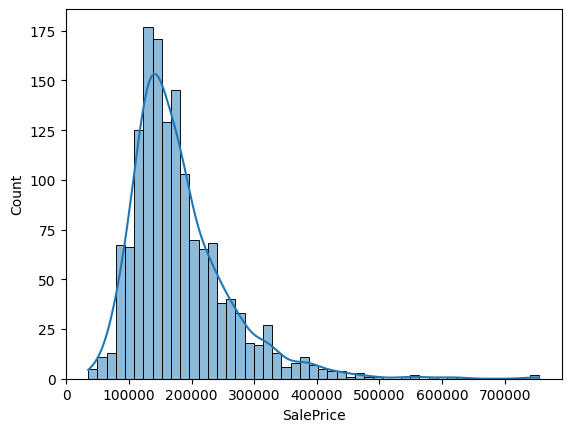

In [14]:
sns.histplot(train["SalePrice"], kde = True)
# The distribution of sales prices are right-skewed.

<Axes: xlabel='SalePrice', ylabel='Count'>

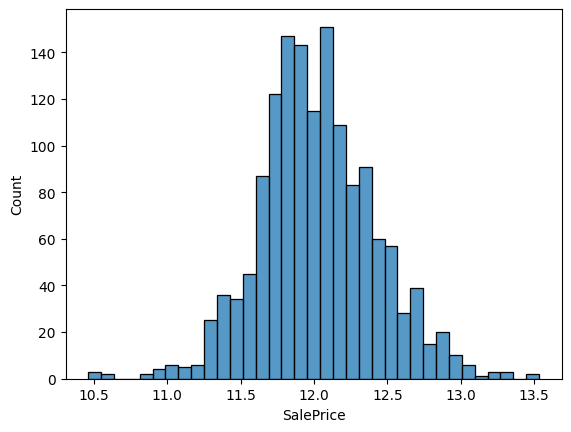

In [15]:
sns.histplot(np.log1p(train["SalePrice"]))

Therefore we need to log transform the sales price.

In [16]:
train["lg_price"] = np.log1p(train["SalePrice"])

In [17]:
results = []

for col in cat_columns :
  groups = []
  for category in train[col].dropna().unique():
    group = train[train[col] == category]["lg_price"]
    if len(group) > 1:
      groups.append(group)

  if len(groups) > 1:
    f_stat,p = f_oneway(*groups)
    results.append((col,p))

anova_results = pd.DataFrame(results, columns = ["Feature", "p_value"])

anova_results = anova_results.sort_values("p_value")

In [18]:
anova_results["log"] = -np.log10(anova_results["p_value"])

In [19]:
anova_results.head(10)

,Feature,p_value,log
7,Neighborhood,4.041201e-243,242.393490
17,ExterQual,6.930372e-195,194.159243
20,BsmtQual,2.029970e-188,187.692510
29,KitchenQual,4.438817e-187,186.352733
33,GarageFinish,4.058066e-151,150.391681
32,GarageType,8.430356e-125,124.074154
31,FireplaceQu,6.961918e-115,114.157271
19,Foundation,1.350599e-111,110.869474
26,HeatingQC,5.222579e-83,82.282115
23,BsmtFinType1,4.320809e-78,77.364435


/tmp/ipykernel_788/2668174751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = anova_results, x = "log", y = "Feature", palette = "deep")


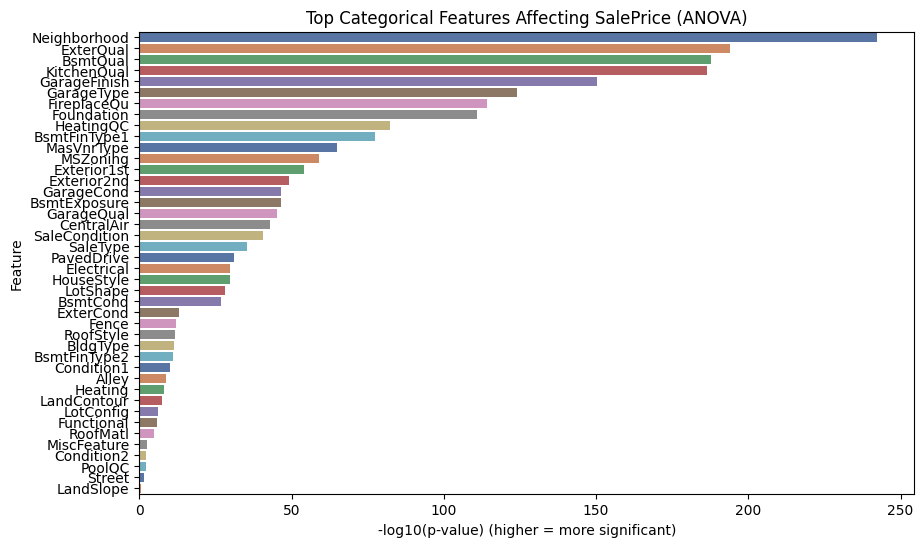

In [20]:
plt.figure(figsize = (10,6))
sns.barplot(data = anova_results, x = "log", y = "Feature", palette = "deep")

plt.title("Top Categorical Features Affecting SalePrice (ANOVA)")
plt.xlabel("-log10(p-value) (higher = more significant)")
plt.show()


If the p_value of a feature is smaller than 0.05, we reject the null hypothesis that the difference of mean sales price in different groups in that feature is insignificant. This suggests that at least category in that feature significantly different sale price.

Features such as Neighborhood, Exterior, Basement, Kitchen, and Garage show extremely small p-values, indicating strong evidence that they are associated with differences in house prices.

On the other hand, features like Street and LandSlope have higher p-values (greater than 0.05), meaning there is insufficient statistical evidence to conclude that their categories significantly affect sale price.

#eta_squared : How much of the variance is explained by the difference in categories.


Variance between groups/ Variance within groups

In [21]:
def eta_squared(df, feature, price):
    overall_mean = df[price].mean()

    ss_between = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for _, group in df.groupby(feature, observed = False)[price] # get all price values in each group
        )


    ss_total = sum((df[price] - overall_mean) ** 2)

    return ss_between / ss_total

effects = []

for col in cat_columns :
  effect = eta_squared(train, col,"lg_price")
  effects.append((col, effect))


explained_var = pd.DataFrame(effects, columns= ["Feature", "Explained variance"]).sort_values(by = "Explained variance", ascending = False)

/tmp/ipykernel_788/709213031.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(explained_var.head(15), x = "Feature", y = "Explained variance", palette = "pastel" )


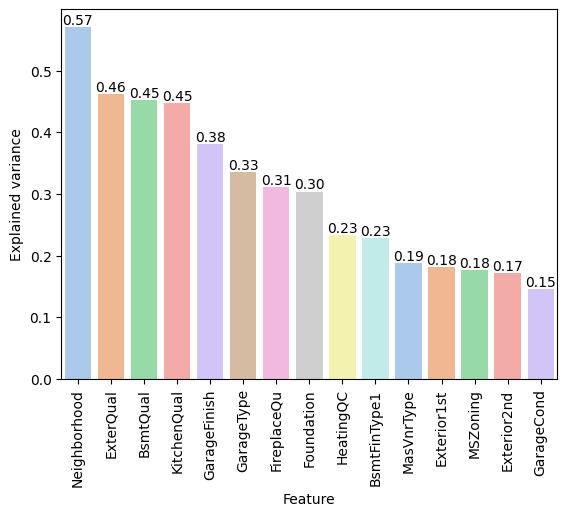

In [22]:
ax = sns.barplot(explained_var.head(15), x = "Feature", y = "Explained variance", palette = "pastel" )

plt.xticks(rotation = 90)

for container in ax.containers :
  ax.bar_label(container, fmt="%.2f")

Features such as Neighborhood, Exterior, Basement, Kitchen, and Garage explain the highest amount of the variance in sale prices. The result of eta_squared analysis align with the ANOVA analysis.

# Numerical features

In [23]:
train.isna().sum().sort_values(ascending = False).head(4)

# LotFrontage: Linear feet of street connected to property
# GarageYrBlt: Year garage was built
# MasVnrArea: Masonry veneer area in square feet

,0
LotFrontage,259
GarageYrBlt,81
MasVnrArea,8
MSZoning,0


In [24]:
for n in ["LotFrontage", "GarageYrBlt", "MasVnrArea"]:
  train[n] = train[n].fillna(0)

# Explore the relationship of each numerical feature with the sale price

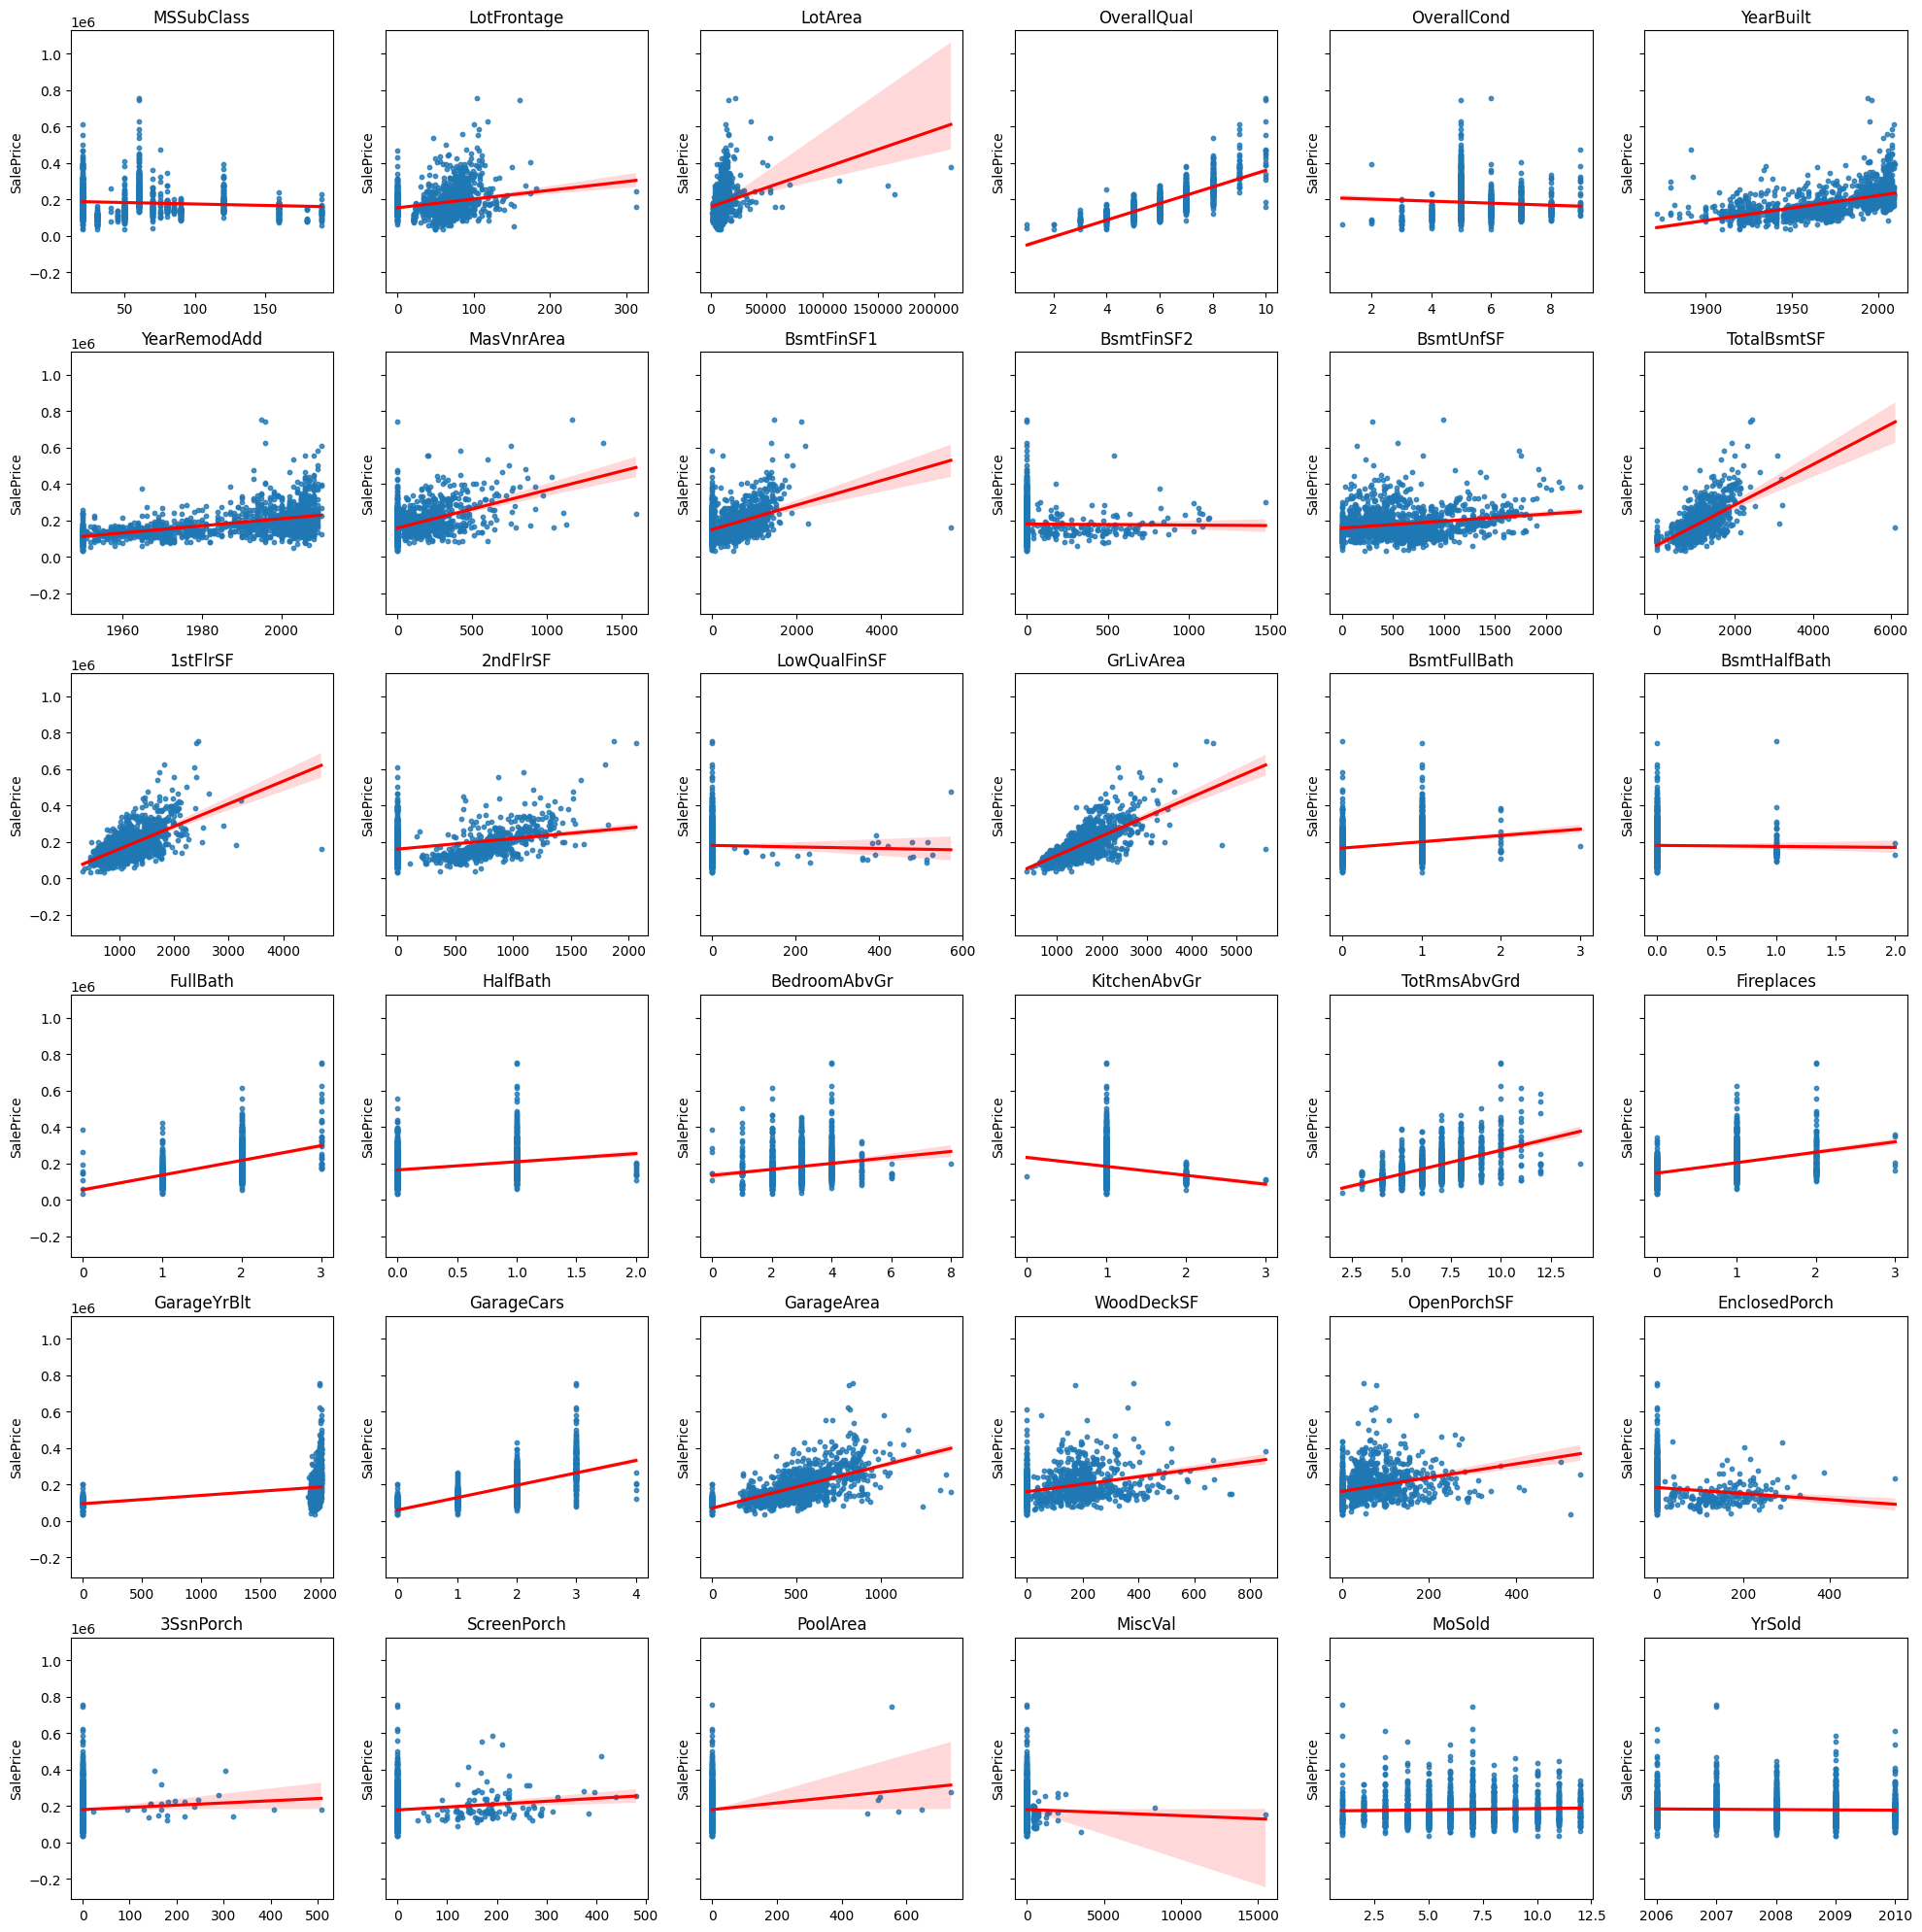

In [25]:
fig, axes = plt.subplots(nrows= 6, ncols=6, figsize = (20,20), sharey = True)

axes = axes.flatten()
for i, col in enumerate(num_columns.drop(["Id", "SalePrice"])):
    ax = axes[i]
    g = sns.regplot(data = train,
                    x = col, y = "SalePrice",
                    scatter_kws={'s':10},
                    line_kws={'color':'red'},
                    ax = ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

The relationship between the features and sale price of the house is very diverse and it is far more than only linear relationship.


I use Catboost to predict house prices.

Catboost is designed to work with a mix of categorical and numerical features, reduces preprocessing on categorical features, can catch the non-linear relationship, handles the interaction among features.

In [26]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [1]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

X = train.drop(["Id", "SalePrice", "lg_price"], axis = 1)
y = train["lg_price"] # np.log1p(train["SalePrice"])

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 42)


ModuleNotFoundError: No module named 'catboost'

In [ ]:
X_train.shape

In [28]:
cat_columns.values

array(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'], dtype=object)

In [33]:
model = CatBoostRegressor(early_stopping_rounds=50, verbose = 0)
param_grid = {
    "depth" :[4, 6, 8, 10],
    "iterations" : [300],
    "learning_rate" : [0.01, 0.03, 0.1, 0.2],
    "l2_leaf_reg" : [1, 3, 5, 7, 9]
}

In [ ]:
grid = RandomizedSearchCV(model,
                          param_grid,
                          n_jobs = -1,
                          verbose = 1,
                          cv = 5,
                          scoring = "neg_root_mean_squared_error",
                          n_iter=15,)
grid.fit(X_train, y_train, cat_features= cat_columns.values)

In [30]:
# model = CatBoostRegressor(verbose = True,
#                            iterations = 1000,
#                            loss_function = "RMSE",
#                           depth = 6,
#                           early_stopping_rounds = 50
#                            )
# model.fit(X_train,y_train, cat_features= cat_columns.values)

# y_pred = model.predict(X_test)


In [31]:
print(f"RMSE: {root_mean_squared_error(y_test,y_pred)}")

NameError: name 'y_pred' is not defined